In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import seaborn as sns

In [2]:
palette = sns.color_palette('deep')
palette

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [3]:
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['font.size'] = 20
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.usetex'] = True

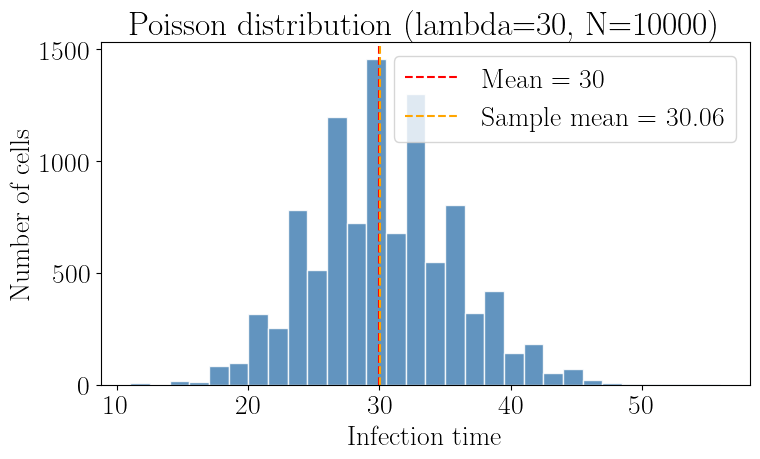

Mean:    30.06
Std dev: 5.49
Variance:30.13


In [4]:
# Parameters
average_life = 30  # min
num_cells = 10000

# Draw samples from Poisson distribution
samples = np.random.poisson(lam=average_life, size=num_cells)

# # Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(samples, bins=30, color='steelblue', edgecolor='white', alpha=0.85)

ax.axvline(average_life, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {average_life}')
ax.axvline(np.mean(samples), color='orange', linestyle='--', linewidth=1.5,
           label=f'Sample mean = {np.mean(samples):.2f}')

ax.set_xlabel('Infection time')
ax.set_ylabel('Number of cells')
ax.set_title(f'Poisson distribution (lambda={average_life}, N={num_cells})')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Mean:    {np.mean(samples):.2f}")
print(f"Std dev: {np.std(samples):.2f}")
print(f"Variance:{np.var(samples):.2f}") # Should be ~= lambda for Poisson

## Virion production

In [4]:
# Load data
df = pd.read_csv('virions_per_cell.csv')
x = df['Time'].values
y = df['Virions'].values
df

,Time,Virions
0,0,0.0000
1,4,140.6250
2,8,2835.9375
3,12,6234.3750
4,16,8625.0000
5,20,10617.1875
6,24,12820.3125
7,28,14390.6250
8,32,14953.1250
9,36,15164.0625


In [5]:
# Define Hill function
def hill(x, A, K, n):
    return A * (x**n) / (K**n + x**n)

# Derivative of Hill function
def hill_derivative(x, A, K, n):
    Kn = K**n
    xn = x**n
    return A * n * Kn * x**(n-1) / (Kn + xn)**2

# Initial guess: A=max, K=midpoint, n=2
p0 = [max(y), np.median(x), 2]

# Fit
popt, pcov = curve_fit(hill, x, y, p0, maxfev=10000,
                       bounds=([0, 0, 0.1], [np.inf, np.inf, 10]))
A, K, n = popt

print(f"A (max) = {A:.4f}")
print(f"K (half-max) = {K:.4f}")
print(f"n (Hill coeff) = {n:.4f}")

# Generate fitted curve and derivative
x_fit = np.linspace(min(x), max(x), 2160)  # 1 point per minute
y_fit = hill(x_fit, *popt)

A (max) = 17703.6603
K (half-max) = 16.1275
n (Hill coeff) = 2.3904


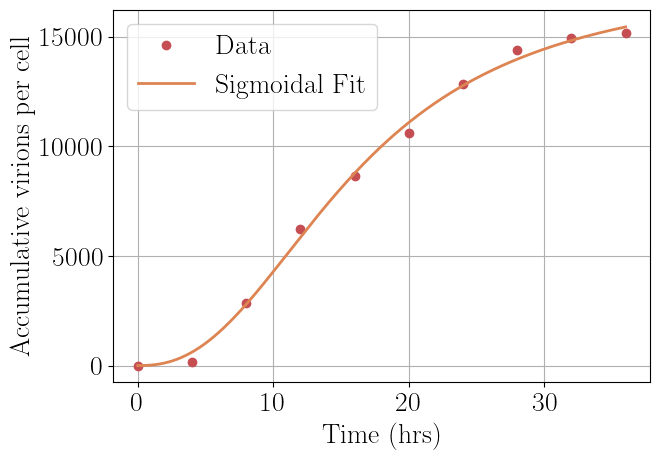

In [6]:
# Plot
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(7,5),facecolor='white')
plt.plot(x, y, 'o', label='Data', color=palette[3])
plt.plot(x_fit, y_fit, '-', lw=2, label='Sigmoidal Fit', color=palette[1])
plt.xlabel('Time (hrs)')
plt.ylabel('Accumulative virions per cell')
plt.legend()
plt.grid(True)
plt.tight_layout()

# plt.savefig('viralProduction.png')
plt.show()

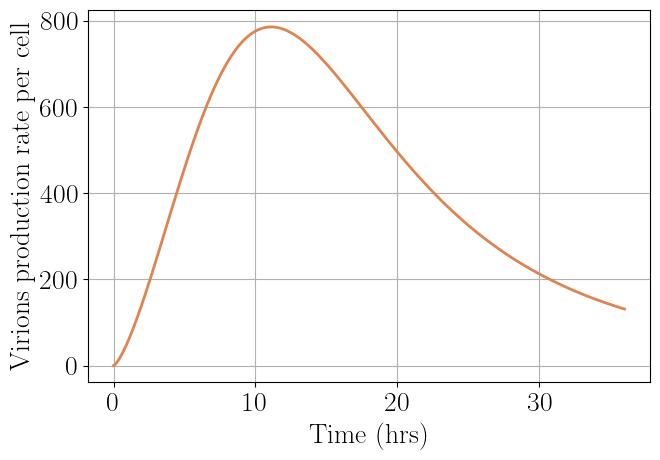

In [7]:
# Virion production rate (derivative)

virionRate = hill_derivative(x_fit, *popt)

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(7,5),facecolor='white')
plt.plot(x_fit, virionRate, '-', lw=2, label='Virion production rate', color=palette[1])
plt.xlabel('Time (hrs)')
plt.ylabel('Virions production rate per cell')
plt.grid(True)
plt.tight_layout()

# plt.savefig('viralRate.png')
plt.show()

## IFN production

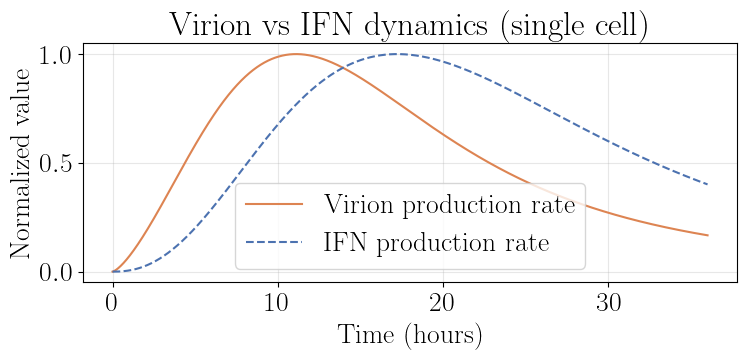

Virion production peak : 11.1 hrs
IFN production peak    : 17.2 hrs
IFN level peak         : 36.0 hrs


In [32]:
# Parameters
k_syn   = 1.0    # dsRNA synthesis rate
k_deg_s = 0.15  # dsRNA decay rate (delay)
k_deg_i = 0.01   # IFN decay rate
pFmax   = 0.00025   # max IFN production rate

dt = x_fit[1] - x_fit[0]  # time step in hours

# Initialize arrays
dsRNA    = np.zeros(len(x_fit))
IFN_rate = np.zeros(len(x_fit))
IFN      = np.zeros(len(x_fit))

# Integrate ODEs
for i in range(1, len(x_fit)):
    dsRNA[i]    = dsRNA[i-1] + dt * (k_syn * virionRate[i-1] - k_deg_s * dsRNA[i-1])
    IFN_rate[i] = pFmax * dsRNA[i]
    IFN[i]      = IFN[i-1] + dt * (IFN_rate[i] - k_deg_i * IFN[i-1])

# Normalize for visualization
virionRate_norm = virionRate / virionRate.max()
IFN_rate_norm   = IFN_rate / IFN_rate.max()
IFN_norm        = IFN / IFN.max()

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_fit, virionRate_norm, label='Virion production rate', color=palette[1])
ax.plot(x_fit, IFN_rate_norm,   label='IFN production rate',    color=palette[0],  linestyle='--')
# ax.plot(x_fit, IFN_norm,        label='IFN level (cumulative)', color='darkorange', linestyle=':')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Normalized value')
ax.set_title('Virion vs IFN dynamics (single cell)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print peak times
print(f"Virion production peak : {x_fit[np.argmax(virionRate)]:.1f} hrs")
print(f"IFN production peak    : {x_fit[np.argmax(IFN_rate)]:.1f} hrs")
print(f"IFN level peak         : {x_fit[np.argmax(IFN)]:.1f} hrs")

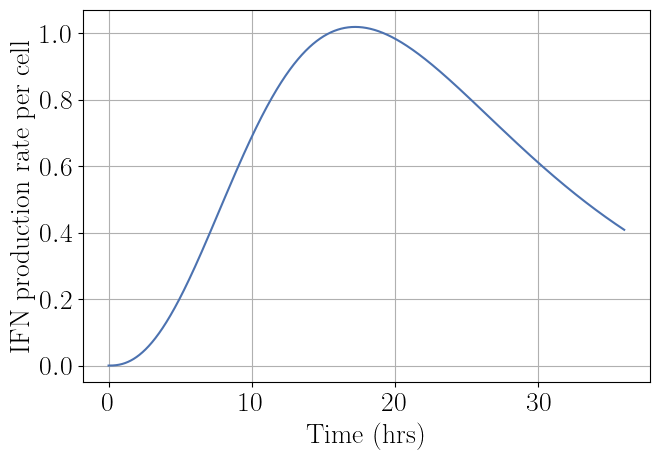

In [34]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(7,5),facecolor='white')
plt.plot(x_fit, IFN_rate, label='IFN production rate',    color=palette[0])
plt.xlabel('Time (hrs)')
plt.ylabel('IFN production rate per cell')
plt.grid(True)
plt.tight_layout()

# plt.savefig('IFNRate.png')
plt.show()

## Diffusion model

$$V_i^+ = (1 - c) \left(V_i + D \sum_j^{n} \left(\frac{V_j - V_i}{d_{ij}^2}\right)\right)$$

$$IFN_i^+ = (1 - c_F) \left(IFN_i + D_F \sum_j^{n} \left(\frac{IFN_j - IFN_i}{d_{ij}^2}\right)\right)$$

In [5]:
def hillFun(x, K, n):
    xn = x**n
    Kn = K**n
    return xn / (Kn + xn)

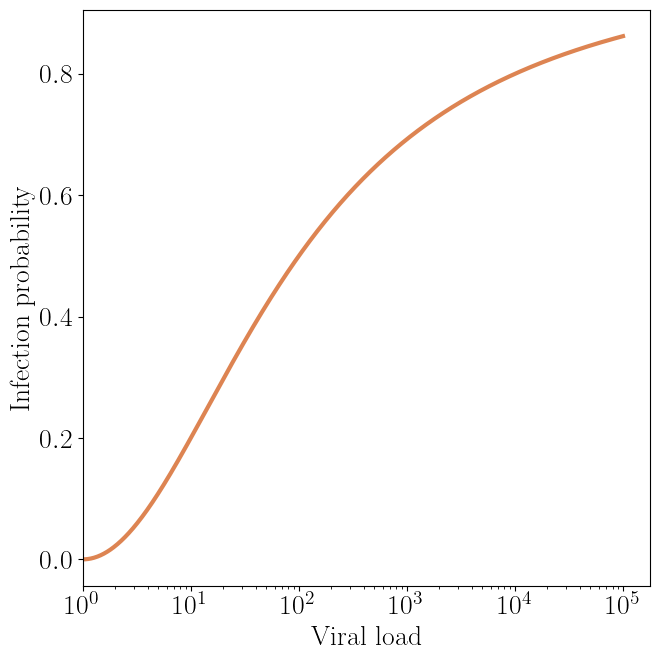

In [6]:
fig, axs = plt.subplots(figsize=(7,7),facecolor='white')

K = 2
n = 2

x = np.linspace(0, 5, num=1000)
xx = 10**(x)
yyV = hillFun(x, K, n)

axs.plot(xx, yyV, lw=3, color=palette[1])
axs.set_xlabel('Viral load')
axs.set_ylabel('Infection probability')
axs.set_xscale('log')
axs.set_xlim((1))

plt.tight_layout()
# plt.savefig('probFunctionV.png')

plt.show()

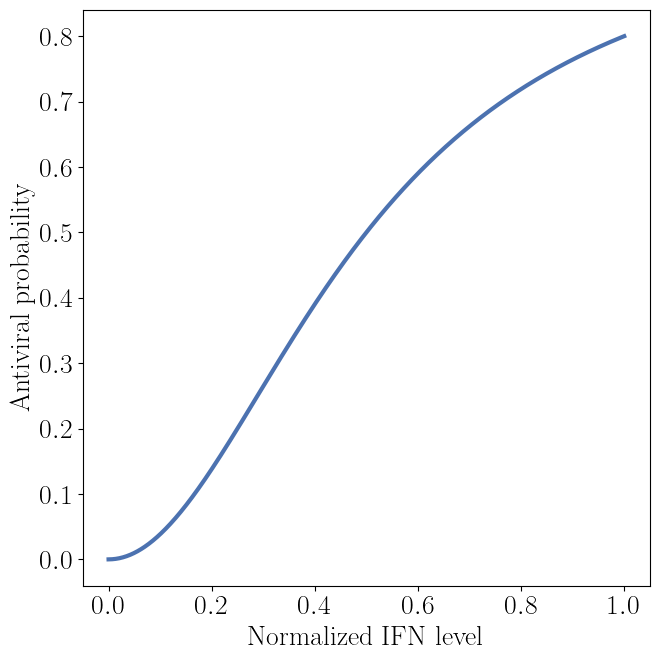

In [7]:
fig, axs = plt.subplots(figsize=(7,7),facecolor='white')

K = 0.5
n = 2

x = np.linspace(0, 1, num=1000)
yyF = hillFun(x, K, n)

axs.plot(x, yyF, lw=3, color=palette[0])
axs.set_xlabel('Normalized IFN level')
axs.set_ylabel('Antiviral probability')

plt.tight_layout()
# plt.savefig('probFunctionIFN.png')

plt.show()

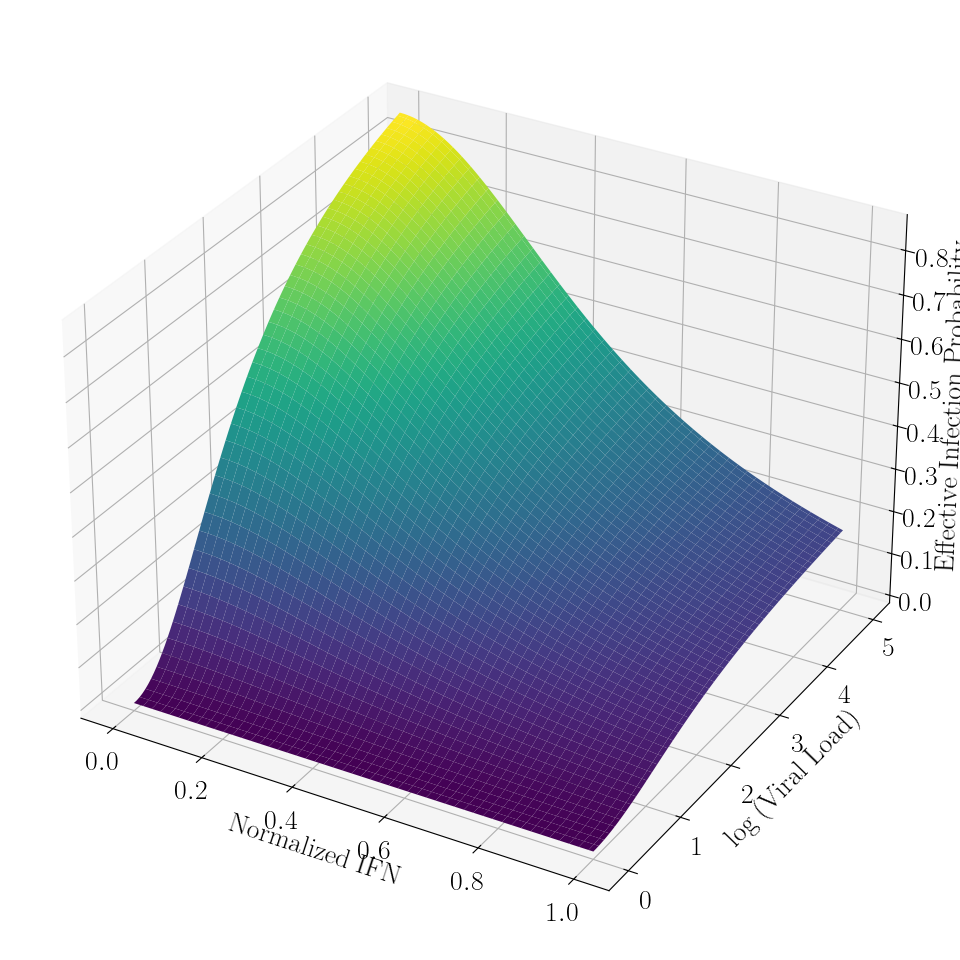

In [43]:
from mpl_toolkits.mplot3d import Axes3D

# Parameters
K_V = 2
n_V = 2
K_F = 0.5
n_F = 2

# Grid for viral load (log10) and IFN
x_vals = np.linspace(0, 5, 100)      # log10(viral load)
y_vals = np.linspace(0, 1, 100)      # normalized IFN

X, Y = np.meshgrid(x_vals, y_vals)

# Compute combined probability
ViralProb = hillFun(X, K_V, n_V)
IFNProb = hillFun(Y, K_F, n_F)
CombinedProb = ViralProb * (1 - IFNProb)

# 3D surface plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(Y, X, CombinedProb, cmap='viridis', edgecolor='none')

ax.set_ylabel('log (Viral Load)')
ax.set_xlabel('Normalized IFN')
ax.set_zlabel('Effective Infection Probability')

plt.tight_layout()

# plt.savefig('effProbInf.png')
plt.show()